### OVERALL MODEL SUMMARY    
The performance metrics and feature importance from the various classifiers are summarized.

**Import the required libraries**

In [43]:
!pip install groq
from groq import Groq
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler

##Overall Performance Metrics

Load the **performance metrics** of the different classifiers.

In [44]:
# Load the Logistic Regression metrics
lgr_metrics_df = pd.read_csv('lgr_metrics.csv')

print(lgr_metrics_df.head())

      Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model L5  0.733  0.304156   0.116987  0.979866  0.395879        21580


In [45]:
# Load the Decision Tree metrics
dtree_metrics_df = pd.read_csv('dtree_metrics.csv')

print(dtree_metrics_df.head())

      Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model D3  0.839  0.746851   0.262664  0.939597  0.620018        44180


In [46]:
# Load the K-Nearest Neighbors metrics
knn_metrics_df = pd.read_csv('knn_metrics.csv')

print(knn_metrics_df.head())

  K-Neighbors Classifier   AUC  Accuracy  Precision    Recall  F2 Score  \
0               Model K4  0.77  0.464106   0.142566  0.939597  0.443599   

   Profit/Loss  
0        26220  


In [47]:
# Rename 'Model' column
knn_metrics_df = knn_metrics_df.rename(columns={'K-Neighbors Classifier': 'Model'})

print(knn_metrics_df.head())

      Model   AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model K4  0.77  0.464106   0.142566  0.939597  0.443599        26220


In [48]:
# Load the Support Vector Classifier metrics
svc_metrics_df = pd.read_csv('svc_metrics.csv')

print(svc_metrics_df.head())

        SVC    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model S5  0.782  0.475441   0.145228  0.939597  0.448718        26940


In [49]:
# Rename 'Model' column
svc_metrics_df = svc_metrics_df.rename(columns={'SVC': 'Model'})

print(svc_metrics_df.head())

      Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model S5  0.782  0.475441   0.145228  0.939597  0.448718        26940


In [50]:
# Load the Random Forest metrics
rf_metrics_df = pd.read_csv('rf_metrics.csv')

print(rf_metrics_df.head())

  Random Forest    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0      Model R4  0.842  0.739295   0.256881  0.939597  0.613497        43700


In [51]:
# Rename 'Model' column
rf_metrics_df = rf_metrics_df.rename(columns={'Random Forest': 'Model'})

print(rf_metrics_df.head())

      Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model R4  0.842  0.739295   0.256881  0.939597  0.613497        43700


In [52]:
# Load the Keras metrics
keras_metrics_df = pd.read_csv('keras_metrics.csv')

print(keras_metrics_df.head())

       Keras   AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model KE5  0.82  0.610831   0.186078  0.932886  0.517498        34620


In [53]:
# Rename 'Model' column
keras_metrics_df = keras_metrics_df.rename(columns={'Keras': 'Model'})

print(keras_metrics_df.head())

       Model   AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model KE5  0.82  0.610831   0.186078  0.932886  0.517498        34620


In [54]:
# Load the XGBoost metrics
xgb_metrics_df = pd.read_csv('xgb_metrics.csv')

print(xgb_metrics_df.head())

  XGB Classifier   AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0      Model XG2  0.84  0.738035   0.255941  0.939597  0.612423        43620


In [55]:
# Rename the 'Model' column
xgb_metrics_df = xgb_metrics_df.rename(columns={'XGB Classifier': 'Model'})

print(xgb_metrics_df.head())

       Model   AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0  Model XG2  0.84  0.738035   0.255941  0.939597  0.612423        43620


**Combine** the performance metrics dataframes

In [56]:
# Combine the dataframes
overall_metrics_df = pd.concat([lgr_metrics_df, dtree_metrics_df, knn_metrics_df, svc_metrics_df,
                                rf_metrics_df, keras_metrics_df, xgb_metrics_df], ignore_index=True)

print(overall_metrics_df.head(7))

       Model    AUC  Accuracy  Precision    Recall  F2 Score  Profit/Loss
0   Model L5  0.733  0.304156   0.116987  0.979866  0.395879        21580
1   Model D3  0.839  0.746851   0.262664  0.939597  0.620018        44180
2   Model K4  0.770  0.464106   0.142566  0.939597  0.443599        26220
3   Model S5  0.782  0.475441   0.145228  0.939597  0.448718        26940
4   Model R4  0.842  0.739295   0.256881  0.939597  0.613497        43700
5  Model KE5  0.820  0.610831   0.186078  0.932886  0.517498        34620
6  Model XG2  0.840  0.738035   0.255941  0.939597  0.612423        43620


In [57]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F2 Score', 'Profit/Loss']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df['Profit/Loss'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance and Profit/Loss',
        xaxis=dict(title='Model'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='Profit/Loss ($)',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

In [58]:
# Get the best model performance metrics based on profit/loss
best_model_df = overall_metrics_df.loc[[overall_metrics_df["Profit/Loss"].idxmax()]]

best_model_df.head()

,Model,AUC,Accuracy,Precision,Recall,F2 Score,Profit/Loss
1,Model D3,0.839,0.746851,0.262664,0.939597,0.620018,44180


##Overall Feature Importance

Load the **feature importance** of the top three (3) classifiers, namely, **Decision Tree Classifier**, **Random Forest Classifier**, and **XGBoost Classifier**.

In [59]:
# Load the Decision Tree feature importance
dtree_features_df = pd.read_csv('dtree_features.csv')

print(dtree_features_df.head(8))

                feature  importance
0            csat_score    0.329093
1         tenure_months    0.283377
2      payment_failures    0.201975
3        monthly_logins    0.185555
4       survey_response    0.000000
5         gender_Female    0.000000
6           gender_Male    0.000000
7  customer_segment_SME    0.000000


In [60]:
# Rename the 'importance' column
dtree_features_df = dtree_features_df.rename(columns={'importance': 'Decision_Tree'})

print(dtree_features_df.head(8))

                feature  Decision_Tree
0            csat_score       0.329093
1         tenure_months       0.283377
2      payment_failures       0.201975
3        monthly_logins       0.185555
4       survey_response       0.000000
5         gender_Female       0.000000
6           gender_Male       0.000000
7  customer_segment_SME       0.000000


In [61]:
# Load the Random Forest feature importance
rf_features_df = pd.read_csv('rf_features.csv')

print(rf_features_df.head(8))

                  feature     score
0           tenure_months  0.023173
1  tenure_fee_interaction  0.016654
2              csat_score  0.015109
3          monthly_logins  0.011718
4        payment_failures  0.009414
5             escalations  0.008731
6      country_Bangladesh  0.006908
7         email_open_rate  0.005684


In [62]:
# Rename the 'score' column
rf_features_df = rf_features_df.rename(columns={'score': 'Random_Forest'})

print(rf_features_df.head(8))

                  feature  Random_Forest
0           tenure_months       0.023173
1  tenure_fee_interaction       0.016654
2              csat_score       0.015109
3          monthly_logins       0.011718
4        payment_failures       0.009414
5             escalations       0.008731
6      country_Bangladesh       0.006908
7         email_open_rate       0.005684


In [63]:
# Load the XGBoost feature importance
xgb_features_df = pd.read_csv('xgb_features.csv')

print(xgb_features_df.head(8))

                  feature  importance
0              csat_score    0.171166
1           tenure_months    0.134319
2        payment_failures    0.104927
3          monthly_logins    0.063197
4  tenure_fee_interaction    0.037035
5         survey_response    0.018550
6             country_USA    0.017082
7             gender_Male    0.016699


In [64]:
# Rename the 'importance' column
xgb_features_df = xgb_features_df.rename(columns={'importance': 'XGBoost'})

print(xgb_features_df.head(8))

                  feature   XGBoost
0              csat_score  0.171166
1           tenure_months  0.134319
2        payment_failures  0.104927
3          monthly_logins  0.063197
4  tenure_fee_interaction  0.037035
5         survey_response  0.018550
6             country_USA  0.017082
7             gender_Male  0.016699


In [65]:
# Combine feature importance dataframes
feature_comparison_df = (
    dtree_features_df
    .merge(rf_features_df, on='feature', how='outer')
    .merge(xgb_features_df, on='feature', how='outer')
)

print(feature_comparison_df.head(33))

                         feature  Decision_Tree  Random_Forest   XGBoost
0                            age            NaN            NaN  0.012893
1               avg_session_time       0.000000            NaN       NaN
2                    city_Berlin            NaN       0.004754  0.012741
3                    city_London            NaN       0.004613       NaN
4                  city_New York       0.000000            NaN       NaN
5         complaint_type_Service       0.000000            NaN       NaN
6       complaint_type_Technical       0.000000            NaN  0.014604
7                  contract_type            NaN            NaN  0.016150
8             country_Bangladesh            NaN       0.006908  0.015049
9                 country_Canada       0.000000            NaN       NaN
10               country_Germany       0.000000            NaN       NaN
11                   country_USA            NaN            NaN  0.017082
12                    csat_score       0.329093    

In [66]:
# Verify info
feature_comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   feature        33 non-null     object 
 1   Decision_Tree  20 non-null     float64
 2   Random_Forest  10 non-null     float64
 3   XGBoost        20 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.2+ KB


In [67]:
# Assign '0.000000' to 'NaN'
num_cols = feature_comparison_df.columns.drop("feature")
feature_comparison_df[num_cols] = feature_comparison_df[num_cols].fillna(0)

print(feature_comparison_df.head(33))

                         feature  Decision_Tree  Random_Forest   XGBoost
0                            age       0.000000       0.000000  0.012893
1               avg_session_time       0.000000       0.000000  0.000000
2                    city_Berlin       0.000000       0.004754  0.012741
3                    city_London       0.000000       0.004613  0.000000
4                  city_New York       0.000000       0.000000  0.000000
5         complaint_type_Service       0.000000       0.000000  0.000000
6       complaint_type_Technical       0.000000       0.000000  0.014604
7                  contract_type       0.000000       0.000000  0.016150
8             country_Bangladesh       0.000000       0.006908  0.015049
9                 country_Canada       0.000000       0.000000  0.000000
10               country_Germany       0.000000       0.000000  0.000000
11                   country_USA       0.000000       0.000000  0.017082
12                    csat_score       0.329093    

In [68]:
# Sort the datafraame
feature_comparison_df = feature_comparison_df.sort_values(by='Decision_Tree', ascending=False)

print(feature_comparison_df.head(33))

                         feature  Decision_Tree  Random_Forest   XGBoost
12                    csat_score       0.329093       0.015109  0.171166
32                 tenure_months       0.283377       0.023173  0.134319
22              payment_failures       0.201975       0.009414  0.104927
21                monthly_logins       0.185555       0.011718  0.063197
0                            age       0.000000       0.000000  0.012893
5         complaint_type_Service       0.000000       0.000000  0.000000
1               avg_session_time       0.000000       0.000000  0.000000
3                    city_London       0.000000       0.004613  0.000000
2                    city_Berlin       0.000000       0.004754  0.012741
8             country_Bangladesh       0.000000       0.006908  0.015049
9                 country_Canada       0.000000       0.000000  0.000000
10               country_Germany       0.000000       0.000000  0.000000
11                   country_USA       0.000000    

In [69]:
# Find rows with '0.000000' for three classifiers
feature_zero_df = feature_comparison_df[(feature_comparison_df['Decision_Tree'] == 0.000000) & \
      (feature_comparison_df['Random_Forest'] == 0.000000) & (feature_comparison_df['XGBoost'] == 0.000000)]

print(feature_zero_df.head(33))

                   feature  Decision_Tree  Random_Forest  XGBoost
5   complaint_type_Service            0.0            0.0      0.0
1         avg_session_time            0.0            0.0      0.0
9           country_Canada            0.0            0.0      0.0
10         country_Germany            0.0            0.0      0.0
13    customer_segment_SME            0.0            0.0      0.0
4            city_New York            0.0            0.0      0.0
14    discount_applied_Yes            0.0            0.0      0.0
18           gender_Female            0.0            0.0      0.0
24     payment_method_Card            0.0            0.0      0.0
28      signup_channel_Web            0.0            0.0      0.0
29         support_tickets            0.0            0.0      0.0


In [70]:
# Get index list
index_list = feature_zero_df.index.tolist()

print(index_list)

[5, 1, 9, 10, 13, 4, 14, 18, 24, 28, 29]


In [71]:
# Drop rows with zeros only for the three classifiers
feature_comparison_df = feature_comparison_df.drop(index=index_list)

print(feature_comparison_df.head(22))

                         feature  Decision_Tree  Random_Forest   XGBoost
12                    csat_score       0.329093       0.015109  0.171166
32                 tenure_months       0.283377       0.023173  0.134319
22              payment_failures       0.201975       0.009414  0.104927
21                monthly_logins       0.185555       0.011718  0.063197
0                            age       0.000000       0.000000  0.012893
3                    city_London       0.000000       0.004613  0.000000
2                    city_Berlin       0.000000       0.004754  0.012741
8             country_Bangladesh       0.000000       0.006908  0.015049
11                   country_USA       0.000000       0.000000  0.017082
6       complaint_type_Technical       0.000000       0.000000  0.014604
7                  contract_type       0.000000       0.000000  0.016150
16                   escalations       0.000000       0.008731  0.000000
15               email_open_rate       0.000000    

In [72]:
# Scale importances
scaler = MinMaxScaler()
feature_comparison_df.iloc[:, 1:] = scaler.fit_transform(feature_comparison_df.iloc[:, 1:])

print(feature_comparison_df.head(22))

                         feature  Decision_Tree  Random_Forest   XGBoost
12                    csat_score       1.000000       0.651999  1.000000
32                 tenure_months       0.861086       1.000000  0.784728
22              payment_failures       0.613733       0.406259  0.613013
21                monthly_logins       0.563839       0.505654  0.369212
0                            age       0.000000       0.000000  0.075326
3                    city_London       0.000000       0.199053  0.000000
2                    city_Berlin       0.000000       0.205154  0.074434
8             country_Bangladesh       0.000000       0.298123  0.087919
11                   country_USA       0.000000       0.000000  0.099798
6       complaint_type_Technical       0.000000       0.000000  0.085323
7                  contract_type       0.000000       0.000000  0.094353
16                   escalations       0.000000       0.376759  0.000000
15               email_open_rate       0.000000    

In [73]:
# Compute average importance
feature_comparison_df['average_importance'] = (feature_comparison_df[['Decision_Tree','Random_Forest',
                                      'XGBoost']].mean(axis=1)
)

print(feature_comparison_df.head(22))

                         feature  Decision_Tree  Random_Forest   XGBoost  \
12                    csat_score       1.000000       0.651999  1.000000   
32                 tenure_months       0.861086       1.000000  0.784728   
22              payment_failures       0.613733       0.406259  0.613013   
21                monthly_logins       0.563839       0.505654  0.369212   
0                            age       0.000000       0.000000  0.075326   
3                    city_London       0.000000       0.199053  0.000000   
2                    city_Berlin       0.000000       0.205154  0.074434   
8             country_Bangladesh       0.000000       0.298123  0.087919   
11                   country_USA       0.000000       0.000000  0.099798   
6       complaint_type_Technical       0.000000       0.000000  0.085323   
7                  contract_type       0.000000       0.000000  0.094353   
16                   escalations       0.000000       0.376759  0.000000   
15          

In [74]:
# Sort by average importance to get the top features
feature_comparison_df = feature_comparison_df.sort_values('average_importance', ascending=False
)

print(feature_comparison_df.head(22))

                         feature  Decision_Tree  Random_Forest   XGBoost  \
12                    csat_score       1.000000       0.651999  1.000000   
32                 tenure_months       0.861086       1.000000  0.784728   
22              payment_failures       0.613733       0.406259  0.613013   
21                monthly_logins       0.563839       0.505654  0.369212   
31        tenure_fee_interaction       0.000000       0.718675  0.216366   
8             country_Bangladesh       0.000000       0.298123  0.087919   
16                   escalations       0.000000       0.376759  0.000000   
15               email_open_rate       0.000000       0.245270  0.087018   
2                    city_Berlin       0.000000       0.205154  0.074434   
3                    city_London       0.000000       0.199053  0.000000   
30               survey_response       0.000000       0.000000  0.108374   
11                   country_USA       0.000000       0.000000  0.099798   
19          

In [75]:
# Reset index
feature_comparison_df = feature_comparison_df.reset_index(drop=True)
feature_comparison_df.index = feature_comparison_df.index + 1
feature_comparison_df.index.name = "Rank"

feature_comparison_df.head(10)

,feature,Decision_Tree,Random_Forest,XGBoost,average_importance
Rank,,,,,
1,csat_score,1.000000,0.651999,1.000000,0.884000
2,tenure_months,0.861086,1.000000,0.784728,0.881938
3,payment_failures,0.613733,0.406259,0.613013,0.544335
4,monthly_logins,0.563839,0.505654,0.369212,0.479568
5,tenure_fee_interaction,0.000000,0.718675,0.216366,0.311680
6,country_Bangladesh,0.000000,0.298123,0.087919,0.128680
7,escalations,0.000000,0.376759,0.000000,0.125586
8,email_open_rate,0.000000,0.245270,0.087018,0.110763
9,city_Berlin,0.000000,0.205154,0.074434,0.093196


In [76]:
# Move last column to second column
cols = feature_comparison_df.columns.tolist()

# Extract last column
last_col = cols[-1]

# Remove it from the end
cols = cols[:-1]

# Insert it into position 1 (second column)
cols.insert(1, last_col)

# Reorder dataframe
feature_comparison_df = feature_comparison_df[cols]

feature_comparison_df.head(10)

,feature,average_importance,Decision_Tree,Random_Forest,XGBoost
Rank,,,,,
1,csat_score,0.884000,1.000000,0.651999,1.000000
2,tenure_months,0.881938,0.861086,1.000000,0.784728
3,payment_failures,0.544335,0.613733,0.406259,0.613013
4,monthly_logins,0.479568,0.563839,0.505654,0.369212
5,tenure_fee_interaction,0.311680,0.000000,0.718675,0.216366
6,country_Bangladesh,0.128680,0.000000,0.298123,0.087919
7,escalations,0.125586,0.000000,0.376759,0.000000
8,email_open_rate,0.110763,0.000000,0.245270,0.087018
9,city_Berlin,0.093196,0.000000,0.205154,0.074434


In [77]:
# Pick the first ten top feature importance
feature_comparison_df = feature_comparison_df.iloc[:10, :2]

feature_comparison_df.head(10)

,feature,average_importance
Rank,,
1,csat_score,0.884000
2,tenure_months,0.881938
3,payment_failures,0.544335
4,monthly_logins,0.479568
5,tenure_fee_interaction,0.311680
6,country_Bangladesh,0.128680
7,escalations,0.125586
8,email_open_rate,0.110763
9,city_Berlin,0.093196


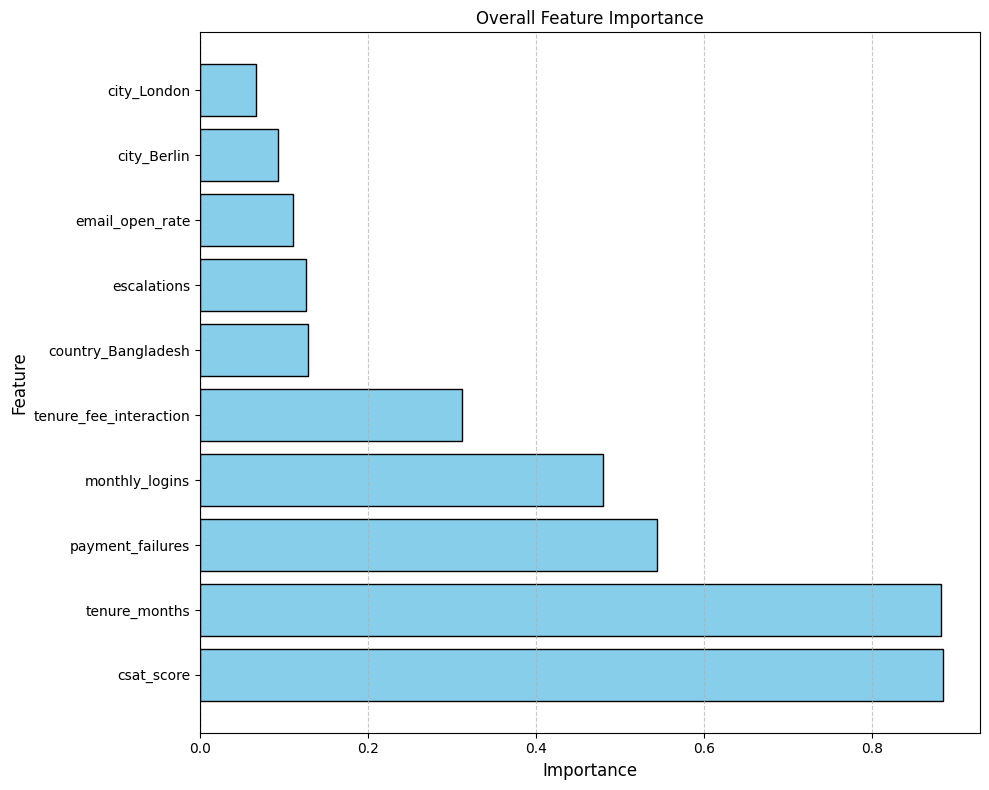

In [78]:
# Plot the feature importance
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_comparison_df['average_importance']]
plt.barh(feature_comparison_df['feature'], feature_comparison_df['average_importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Overall Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Gen AI** narrative on feature importance     
The following codes are commented because the API key can only be accessed locally. However, the Gen AI narrative is captured and shown.

In [79]:
# Convert dataframe to string format
#data_string = feature_comparison_df.to_string(index=False).replace('\n', ' ')
#data_dict = {"data": data_string}

In [80]:
# Provide the API key
#import os

#client = Groq(
#    api_key=os.getenv("GROQ_API_KEY")
#)

In [81]:
# Send the feature importance data for analysis
#chat_completion = client.chat.completions.create(
#    messages=[
#        {"role": "user", "content": f"Analyze the following feature importance data on customer churn: {data_dict['data']}"}
#    ],
#    model="llama-3.1-8b-instant",
#)

#narrative = chat_completion.choices[0].message.content
#narrative = narrative.replace('\n', ' ')

In [82]:
# Obtain the narrative or report from the GenAI model
#from IPython.display import Markdown

#Markdown(narrative)

##Gen AI narrative on feature importance

Based on the feature importance data, here are some key insights and observations: Top Important Features: 1. csat_score (0.884): The customer satisfaction score is the most important feature, indicating that customer satisfaction is a critical factor in predicting customer churn. This suggests that addressing customer concerns and improving overall customer experience can help retain customers. 2. tenure_months (0.882): Customer tenure is the second most important feature, indicating that longer-term customers are more likely to churn. This suggests that customers who have been with the company for a long time may be more at risk of leaving. 3. payment_failures (0.544): Payment failures are an important indicator of customer churn. This suggests that issues related to payment processing, billing, or financial difficulties can lead to customer dissatisfaction and churn. Features with Moderate Importance: 1. monthly_logins (0.480): Monthly logins indicate customer engagement, and a lack of engagement (i.e., infrequent logins) can be a sign of churn. This suggests that customers who are not actively using the service may be more likely to leave. 2. tenure_fee_interaction (0.312): The way tenure intersects with fee-related issues (e.g., pricing, pricing changes) seems to be somewhat significant, however, the exact relationship between these is unclear. Features with Lower Importance: 1. country_Bangladesh (0.129): The country of residence has a relatively low importance in predicting customer churn. This suggests that geographic location may not be a significant factor in determining customer loyalty. 2. escalations (0.126): Escalations (i.e., issues escalated to higher-level support) are not a significant predictor of customer churn. This suggests that while escalations may indicate quality issues, they are not a primary driver of churn. 3. email_open_rate (0.111): Customer engagement metrics (e.g., email open rates) are relatively low in importance, indicating that they may not be a significant predictor of customer churn. 4. city_Berlin (0.093): The city of residence also has a relatively low importance in predicting customer churn. 5. city_London (0.067): Like other geographic features, the city of London has a low importance in predicting customer churn. Takeaways: 1. Focus on customer satisfaction and experience: The high importance of csat_score suggests that improving customer satisfaction through better support, communication, and quality is critical. 2. Pay attention to payment and billing: Payment failures and issues related to payment processing can lead to churn, so addressing these issues is essential. 3. Monitor engagement metrics: While not as critical, monthly logins and email open rates can still indicate customer engagement or disengagement, which may be useful in early identification of potential churn. 4. Consider tenure-based insights: Analyze customer tenure to identify potential churn risks, and consider ways to retain long-term customers (e.g., loyalty programs, special offers). 5. Rethink geographic factors: The relatively low importance of geographic features (e.g., country, city) suggests that they may not be significant drivers of customer churn.

## OVERALL MODEL SUMMARY  

Based on the metrics of  AUC, Accuracy, Precision, Recall, F2 Score, and Profit/Loss, the **Decision Tree Classifier** is the winner. **Random Forest Classifier** and **XGBoost Classifier** are virtually tied for the second place.

For this particular dataset, the **Decision Tree Classifier**  is the recommended machine learning algorithm.    

The **feature importance** is consistent with what is highlighted in the **Heatmap of Significant Correlations** in the following order: `csat_score`, `tenure_months`, `payment_failures`, and `monthly_logins`.

##Next Steps and Further Recommendations    
- Confirm the model that will suit the business needs in terms of the optimal level of churn identification and precision.    
- Continue model development to include actual identification of clients who are likely to churn.
- Tune the thresholds to maximize profit using realistic lifetime value and cost of retention assumptions.
- Deploy and apply the model for the use of relevant business groups like marketing teams for retention campaigns, customer support teams for proactive outreach, and product teams for feature improvements. Leadership can also be guided by the model for churn strategy and forecasting.     
- Continue model development to validate the features relative importance to guide management on which features need to be given particular attention in order to prevent churn.

Churn in this dataset is primarily driven by customer satisfaction and engagement levels rather than pricing. Improving user experience and increasing product adoption would likely have the strongest impact on reducing churn.